# In this notebook

I want to explore how much the signal contaminates the data power spectrum when the signal window *is* included in the welch average.
I want to then build a little class such that the contaminated noise power spectrum can be calculated via data.dirty_noise_estimate() or similar.

In [26]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import nifty8 as ift

def unpickle_me_this(filename: str, absolute_path=False):
    if absolute_path:
        file = open(filename, 'rb')
    else:
        file = open(filename, 'rb')
    data = pickle.load(file)
    file.close()
    return data

def pickle_me_this(filename: str, data_to_pickle: object):
    path = filename + ".pickle"
    file = open(path, 'wb')
    pickle.dump(data_to_pickle, file)
    file.close()


In [3]:
# -- Set a GPS time:
t0 = 1126259462.4    # -- GW150914
center = int(t0)  #-- Round GPS time to nearest second
#-- Choose detector as H1, L1, or V1
detector = 'H1'
strain = unpickle_me_this("data/GW150914_strain.pickle")
data = 1e19 * strain.value
# data = strain.value


zero_time = 1126259446  # I got this zero time by looking at the caption of the figure produced by strain.plot().
time = np.array(strain.times) - zero_time  # in seconds
onset = t0 - zero_time

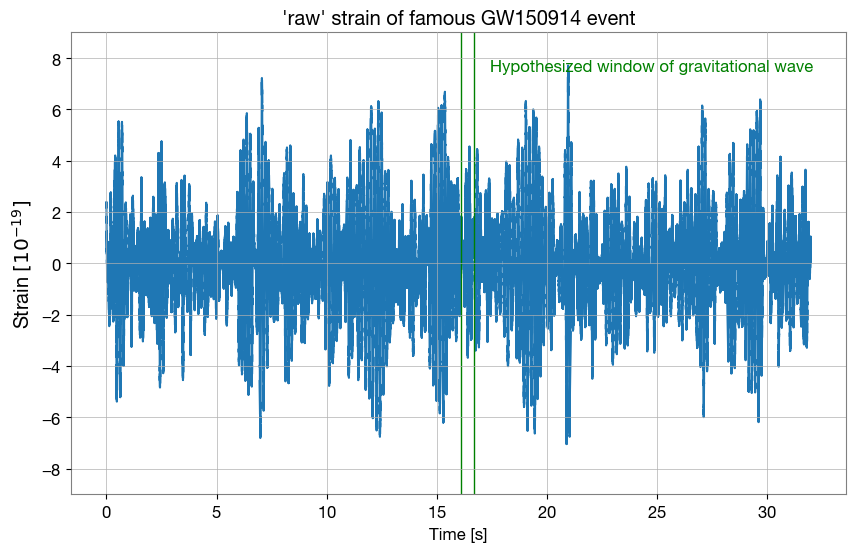

In [4]:
fig = plt.figure(figsize=(10,6))
plt.plot(time, data)
plt.title("'raw' strain of famous GW150914 event")
plt.text(onset+1, 7.5, "Hypothesized window of gravitational wave", color='g')
plt.ylim(-9, 9)
plt.vlines([onset - 0.3, onset + 0.3], -10, 10, color="green", lw=1)
plt.ylabel(r"Strain $[10^{-19}]$")
plt.xlabel("Time [s]", fontsize=12)
plt.show()

# Procedure

1. We take the big dataset over the 30 seconds, cut out the green window where the gravitational wave is hypothesized to be. This cuts the long data strip in small data strip 1 and 2.
2. We build windows in each smaller data strip of that overlap with each other 50% of the time to maximize the number of windows. The windows should enforce periodic boundary conditions onto the data for the fourier transform. We try to maximize the window maximal length to get a fine resolution in fourier space. At the same time, let's aim for at least 10 power spectra.
3. We fourier transform all windows, get the power spectra and build the average of all power spectra.

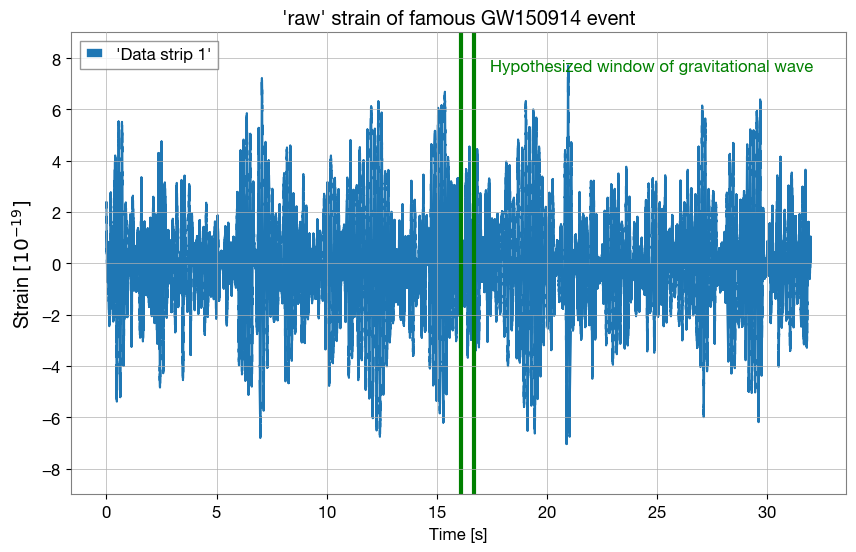

In [13]:
# Actually: Now let's here put a trivial condition, such that actually NO indices get cut off.

cond_1 = np.where(time < np.inf)
cond_2 = np.where(time > (-np.inf))
data_strip_1 = data[cond_1]
time_in_strip_1 = time[cond_1]
data_strip_2 = data[cond_2]
time_in_strip_2 = time[cond_2]

fig2 = plt.figure(figsize=(10,6))
plt.plot(time_in_strip_1, data_strip_1, label="'Data strip 1'")
# plt.plot(time_in_strip_2, data_strip_2, label="'Data strip 2'")
plt.title("'raw' strain of famous GW150914 event")
plt.text(onset+1, 7.5, "Hypothesized window of gravitational wave", color='g')
plt.ylim(-9, 9)
plt.vlines([onset - 0.3, onset + 0.3], -10, 10, color="green", lw=3)
plt.ylabel(r"Strain $[10^{-19}]$")
leg = plt.legend(loc="upper left")
plt.xlabel("Time [s]", fontsize=12)
plt.show()

In [219]:

# only "left dataset" = dataset exists, no splitting anymore..

length_of_windows = 0.5

lf_edges_ds1 = np.arange(0, max(time_in_strip_1), length_of_windows/2)
r_edges_ds1 = lf_edges_ds1+length_of_windows


edges_ds1_too_far_right = np.where(r_edges_ds1 > np.max(time_in_strip_1))
r_edges_ds1 = np.delete(r_edges_ds1, edges_ds1_too_far_right)
lf_edges_ds1 = np.delete(lf_edges_ds1, edges_ds1_too_far_right)



Rectangle  64  (machine counting) is signal contaminated : ( 16.0 ,  16.5 ) s
Rectangle  65  (machine counting) is signal contaminated : ( 16.25 ,  16.75 ) s


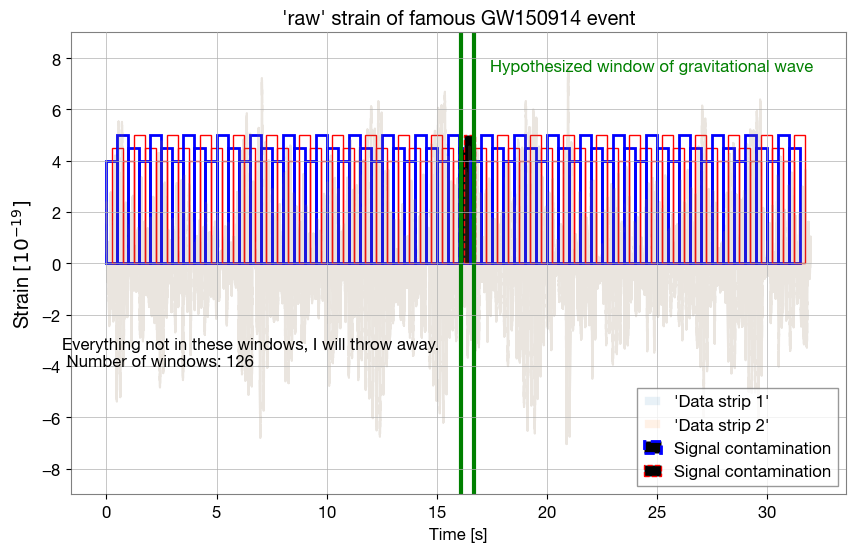

We also see now that there will be two windows in which the signal contaminate the noise power spectrum estimate.


In [220]:
fig3, ax = plt.subplots(figsize=(10,6))
plt.plot(time_in_strip_1, data_strip_1, label="'Data strip 1'", alpha=.1)
plt.plot(time_in_strip_2, data_strip_2, label="'Data strip 2'", alpha=.1)
plt.title("'raw' strain of famous GW150914 event")
plt.text(onset+1, 7.5, "Hypothesized window of gravitational wave", color='g')
plt.ylim(-9, 9)
plt.vlines([onset - 0.3, onset + 0.3], -10, 10, color="green", lw=3)
plt.ylabel(r"Strain $[10^{-19}]$")
leg2 = plt.legend(loc="upper left")


# Plot Rectangles to visualize
heights = [4, 4.5, 5] * len(lf_edges_ds1)
for i, (left, right) in enumerate(zip(lf_edges_ds1, r_edges_ds1)):
    width = right - left
    if i%2 != 0:
        c = (1,0,0)
        lw=1
        height = 4
    else:
        c= (0,0,1)
        lw=2
        height = 5

    if (left < onset) & (onset < left+width):
        print("Rectangle ", i , " (machine counting) is signal contaminated : (", left, ", ", left+width,") s")
        rect = Rectangle((left, 0), width, heights[i], facecolor='black', linewidth=lw, edgecolor=c, ls="--", label="Signal contamination")
    else:
        rect = Rectangle((left, 0), width, heights[i], facecolor='none', linewidth=lw, edgecolor=c)
    ax.add_patch(rect)


# Plot Rectangles to visualize
# for i, (left, right) in enumerate(zip(lf_edges_ds2, r_edges_ds2)):
#     width = right - left
#     if i%2 != 0:
#         c = (1,0,0)
#         lw=1
#         height = 4
#     else:
#         c= (0,0,1)
#         lw=2
#         height = 5
#     rect = Rectangle((left, 0), width, heights[i], facecolor='none', linewidth=lw, edgecolor=c)
#     ax.add_patch(rect)

plt.legend()
plt.text(-2,-4,f"Everything not in these windows, I will throw away.\n Number of windows: {len(lf_edges_ds1)}", fontsize=12)
plt.xlabel("Time [s]", fontsize=12)
plt.show()

print("We also see now that there will be two windows in which the signal contaminate the noise power spectrum estimate.")

In [221]:
collection_of_small_datasets_strain = []
collection_of_small_datasets_times = []

for left_lim, right_lim in zip(lf_edges_ds1, r_edges_ds1):
    idcs = np.where((time > left_lim) & (time < right_lim))
    collection_of_small_datasets_strain.append(data[idcs])
    collection_of_small_datasets_times.append(time[idcs])

# for left_lim, right_lim in zip(lf_edges_ds2, r_edges_ds2):
#     idcs = np.where((time > left_lim) & (time < right_lim))
#     collection_of_small_datasets_strain.append(data[idcs])
#     collection_of_small_datasets_times.append(time[idcs])

Let's plot this so we are sure we can reconstruct the full set from the little window data

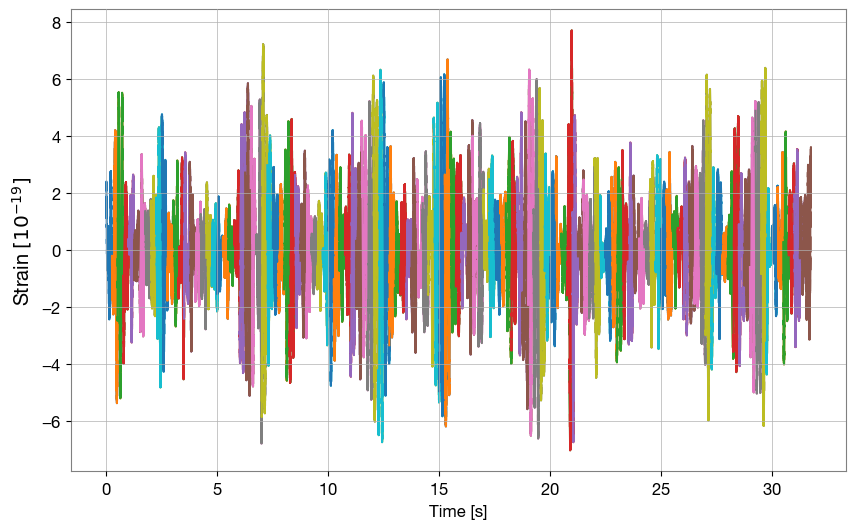

In [222]:

fig4 = plt.figure(figsize=(10,6))
for d, t in zip(collection_of_small_datasets_strain, collection_of_small_datasets_times):
    plt.plot(t, d)

plt.ylabel(r"Strain $[10^{-19}]$")
plt.xlabel("Time [s]", fontsize=12)
plt.show()

Now, we shall enforce artificial periodicity in each little data window..

In [223]:
from scipy.signal.windows import tukey

In [224]:
print(collection_of_small_datasets_strain[0], len(collection_of_small_datasets_strain[0]))
collection_of_small_datasets_strain_windowed = [el*tukey(M=len(el), alpha=0.1, sym=True) for el in collection_of_small_datasets_strain]
print("length of small windows: ", max(collection_of_small_datasets_times[0])-min(collection_of_small_datasets_times[0]))

[ 2.087639    2.39681183  2.2867223  ... -2.52680736 -2.30982967
 -2.55989243] 2047
length of small windows:  0.49951171875


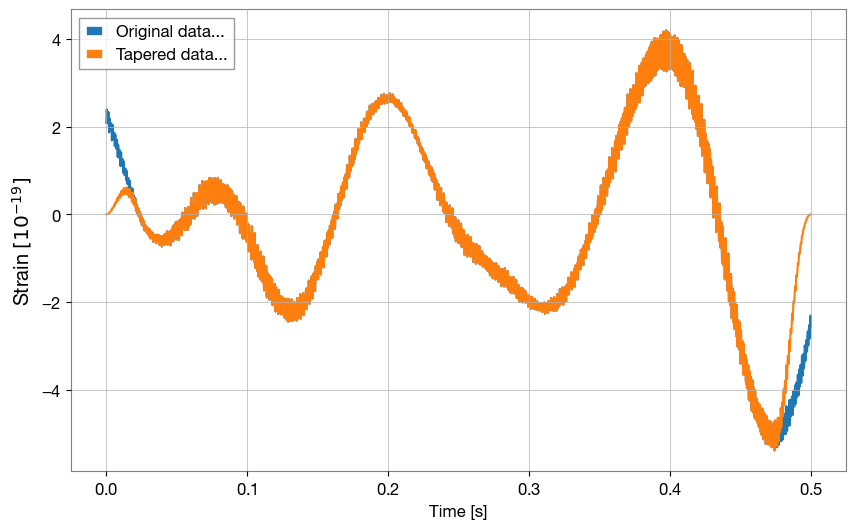

In [225]:
fig5 = plt.figure(figsize=(10,6))
plt.xlabel("Time [s]", fontsize=12)
plt.ylabel("Strain $[10^{-19}]$")

plt.plot(collection_of_small_datasets_times[0], collection_of_small_datasets_strain[0], label="Original data...")
plt.plot(collection_of_small_datasets_times[0], collection_of_small_datasets_strain_windowed[0], label="Tapered data...")
plt.legend()
plt.show()

Let's build the power spectrum.

In [226]:
def power_analyze_my_field(field_to_analyze, ht_operator):
    """
    For a stationary field, this function extracts k_lengths and the power spectrum.

    :param field_to_analyze:    A field defined over a regular grid space that contains the real space field values from which to extract the power spectrum.
    :param ht_operator:         The operator that transforms between the real space and harmonic space.
    :return:
    """
    ps = ift.power_analyze(ht_operator(field_to_analyze))
    return ps.domain[0].k_lengths, ps

exemplary_time_domain_values = collection_of_small_datasets_times[0]
n_dtps = len(exemplary_time_domain_values)
L = max(exemplary_time_domain_values)-min(exemplary_time_domain_values)
time_domain = ift.RGSpace((n_dtps, ), distances=L/n_dtps)
time_domain_tuple = ift.DomainTuple.make(time_domain, )
HT = ift.HartleyOperator(time_domain_tuple)

window_fields = [ift.Field(time_domain_tuple, val=small_data) for small_data in collection_of_small_datasets_strain_windowed]


In [227]:
tupled_result = [power_analyze_my_field(el, HT) for el in window_fields]

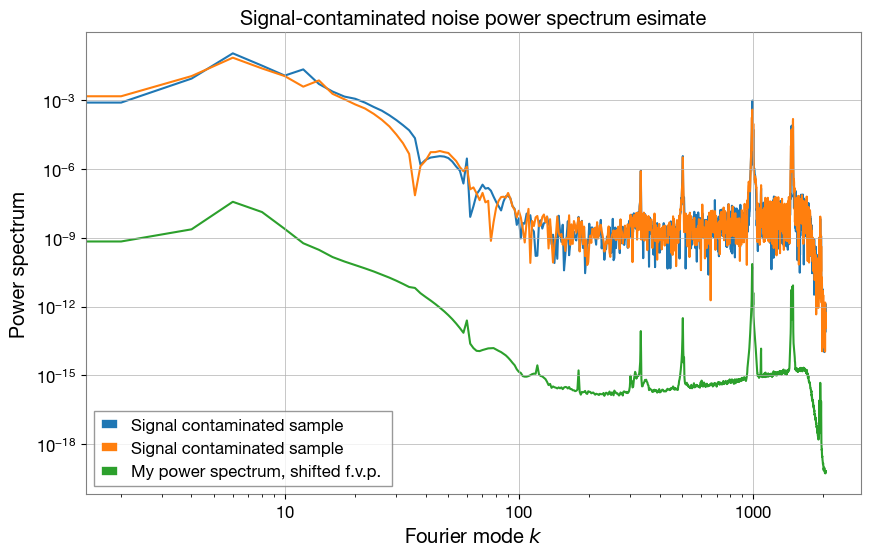

In [228]:
k_lengths, power_spectrum_samples = zip(*tupled_result)
power_spectrum_domain = power_spectrum_samples[0].domain
k_length = k_lengths[0]
mean_power_spectrum_val = np.mean([pss.val for pss in power_spectrum_samples], axis=0)
power_spectrum = ift.Field(power_spectrum_domain, val=mean_power_spectrum_val)


fig6 = plt.figure(figsize=(10,6))

for idx, ps_sample in enumerate(power_spectrum_samples):
    if (idx == 15) or (idx == 16):
        plt.plot(k_length, ps_sample.val,  label="Signal contaminated sample")
        # pass
    else:
        # plt.plot(k_length, ps_sample.val, alpha=0.5, color="black")
        pass




plt.plot(k_length, power_spectrum.val*1e-7, label="My power spectrum, shifted f.v.p. ")
plt.loglog()
plt.xlabel("Fourier mode $k$")
plt.ylabel("Power spectrum")
plt.title("Signal-contaminated noise power spectrum esimate")
plt.legend()
plt.show()


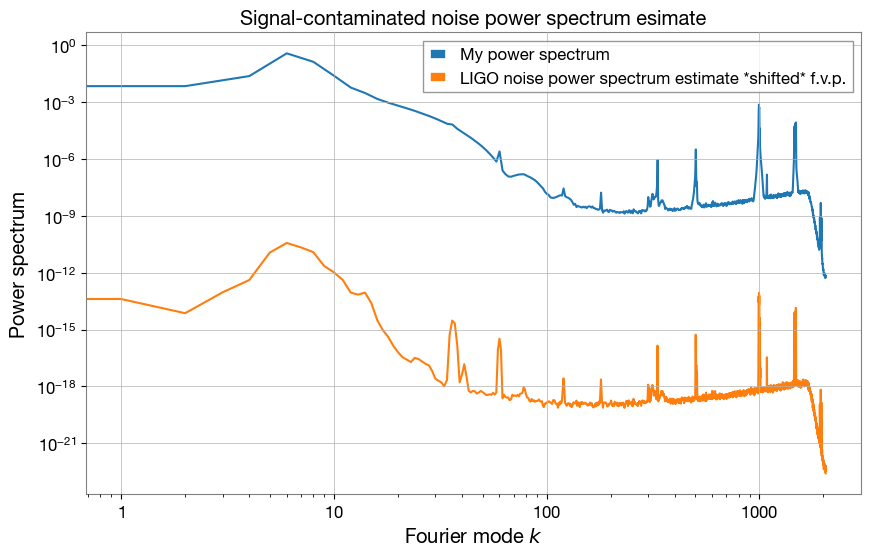

In [229]:

strain = unpickle_me_this("data/GW150914_strain.pickle")
asd = strain.asd(fftlength=1)
norm = max(asd.value)/max(np.sqrt(power_spectrum.val))
asd /= norm

fig7 = plt.figure(figsize=(10,6))

plt.plot(k_length, power_spectrum.val, label="My power spectrum")
plt.plot(asd.frequencies, asd.value ** 2 * 1e-10, label="LIGO noise power spectrum estimate *shifted* f.v.p.")
plt.loglog()
# plt.vlines(10, 1e-11, 1, label="Something 'wrong' with the data happens left to this line. Let's ignore this for now", color="red")
plt.xlabel("Fourier mode $k$")
plt.ylabel("Power spectrum")
plt.title("Signal-contaminated noise power spectrum esimate")
plt.legend()
plt.show()

## Intermediate Result

I see no additional features at all in those power spectrum samples that are contaminated by the signal.
To sanity, we will Fourier transform a field centered on the signal window a.) broadly and then b.) tightly to see how the features change in these cases and where there are any to detect by comparing again versus the average power spectrum.

But really, there MUST be an additional feature, since whitening with just the noise power spectrum (i.e. taking the ratio of (P_n+P_s)/P_n does NOT give just white noise...

In [230]:
# pickle_me_this("results_from_welch_averaging_data", [time_domain, k_length, power_spectrum])

[ 0.55884668  0.877058    0.68710528 ... -1.6359667  -2.09887003
 -2.4077008 ] 1433


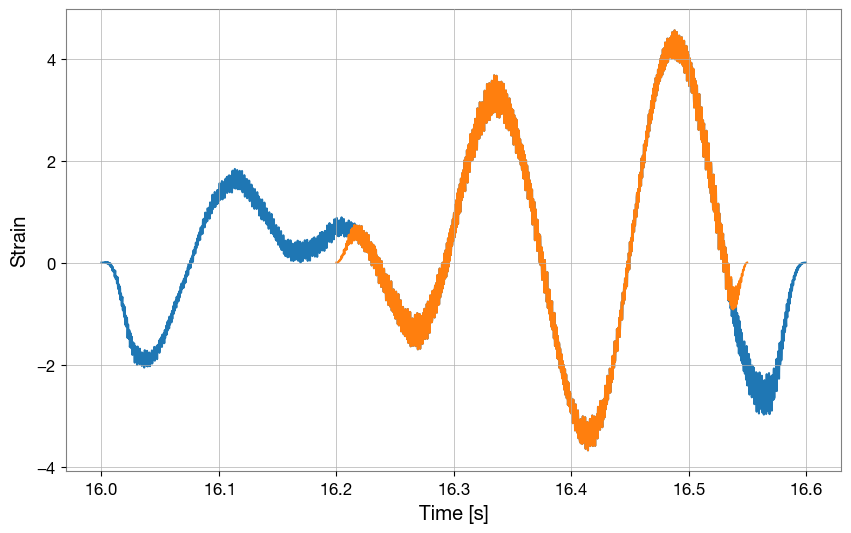

In [231]:
strict_interval = np.where((time_in_strip_1 > 16.2) & (time_in_strip_2 < 16.55))
looser_interval = np.where((time_in_strip_1 > 16) & (time_in_strip_2 < 16.6))

stricter_data = data_strip_1[strict_interval]
stricter_time = time_in_strip_1[strict_interval]

looser_data = data_strip_1[looser_interval]
looser_time = time_in_strip_1[looser_interval]

print(stricter_data, len(stricter_data))

stricter_data = stricter_data * tukey(len(stricter_data), alpha=0.1)
looser_data = looser_data * tukey(len(looser_data), alpha=0.1)

fig8 = plt.figure(figsize=(10,6))

plt.plot(looser_time, looser_data, label="Loose time window")
plt.plot(stricter_time, stricter_data, label="Stricter time window")
plt.xlabel("Time [s]")
plt.ylabel("Strain")
plt.show()


In [232]:
n_dtps_strict = len(stricter_time)  # adjust
L_strict = max(stricter_time)-min(stricter_time) # adjust

time_domain_strict = ift.RGSpace((n_dtps_strict, ), distances=L_strict/n_dtps_strict)
time_domain_tuple_strict = ift.DomainTuple.make(time_domain_strict, )
HT_stricter = ift.HartleyOperator(time_domain_tuple_strict)

n_dtps_looser = len(looser_time)  # adjust
L_looser = max(looser_time)-min(looser_time) # adjust

time_domain_looser = ift.RGSpace((n_dtps_looser, ), distances=L_looser/n_dtps_looser)
time_domain_tuple_looser = ift.DomainTuple.make(time_domain_looser, )
HT_looser= ift.HartleyOperator(time_domain_tuple_looser)

window_field_strict = ift.Field(time_domain_tuple_strict, val=stricter_data)
window_field_looser = ift.Field(time_domain_tuple_looser, val=looser_data)

tupled_result_strict = power_analyze_my_field(window_field_strict, HT_stricter)
tupled_result_looser = power_analyze_my_field(window_field_looser, HT_looser)

k_strict, ps_sample_strict = tupled_result_strict
k_looser, ps_sample_looser = tupled_result_looser


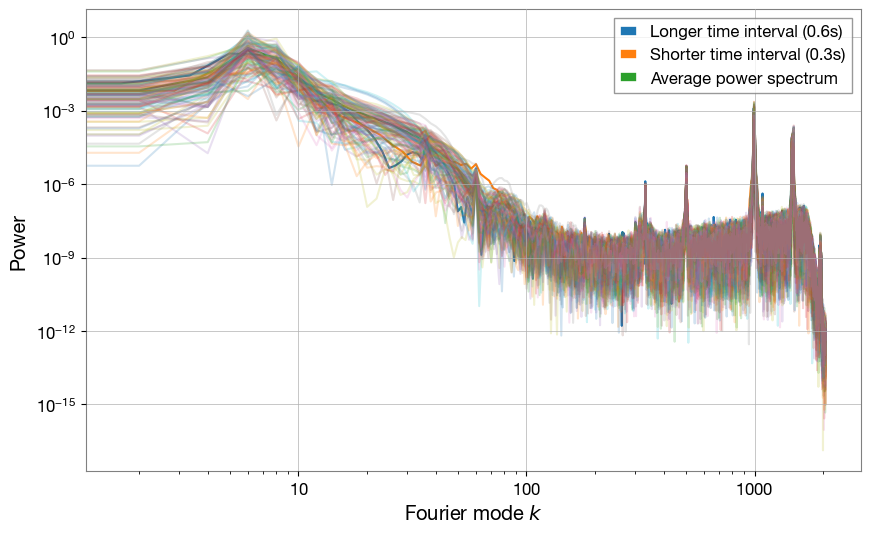

samples that we average over:  126


In [233]:
fig9 = plt.figure(figsize=(10,6))

add_offset = False  # if false, plots all samples, not just one random and doesn't shift anything
add_bounds = False  # if True and add_offset False plots also the largest and smallest (by measure of field^T field) of the empirical power spectrum estimates in the data stream

if add_offset:
    plt.plot(k_looser, ps_sample_looser.val, label="Longer time interval (0.6s)")
    plt.plot(k_strict, ps_sample_strict.val*1e7, label="Shorter time interval  (0.3s) (shifted f.v.p.)")
    plt.plot(k_length, power_spectrum.val*1e-7, label="Average power spectrum (shifted f.v.p.)")
    plt.plot(k_length, power_spectrum_samples[10].val*1e-10,  label="Random sample (shifted f.v.p.)")

else:
    plt.plot(k_looser, ps_sample_looser.val, label="Longer time interval (0.6s)")
    plt.plot(k_strict, ps_sample_strict.val, label="Shorter time interval (0.3s)")
    plt.plot(k_length, power_spectrum.val, label="Average power spectrum")
    for idx, el in enumerate(power_spectrum_samples):
        if (idx!=15) and (idx!=16):
            plt.plot(k_length, el.val, alpha=0.2)
            # pass
        else:
            # plt.plot(k_length, el.val, alpha=0.5, color="Black")
            pass

    if add_bounds:
        inner_products = [np.dot(arr.val, arr.val) for arr in power_spectrum_samples]  # get a metric of 'largeness'

        # Get index of maximum and min
        max_index = np.argmax(inner_products)
        min_index = np.argmin(inner_products)

        # Get the corresponding field
        max_field = power_spectrum_samples[max_index]
        min_field = power_spectrum_samples[min_index]

        plt.plot(k_length, max_field.val, label=r"Upper bound on field realizations ($\mathrm{field}_{\mathrm{max}}$)", color="blue", )
        plt.plot(k_length, min_field.val, label=r"Lower bound on field realizations ($\mathrm{field}_{\mathrm{min}}$)", color="red",)


plt.loglog()
plt.xlabel("Fourier mode $k$")
plt.ylabel("Power")
plt.legend()
plt.show()

print("samples that we average over: ", len(power_spectrum_samples))

Again, no features seen... what happens if we whiten now the data in the signal strip with the actual power spectrum? Will we get something white or structured?

_Correction_: When you plot all other samples as well, there is one obvious difference: More power in the regime 20 - 100 Hz for windows containing the signal....

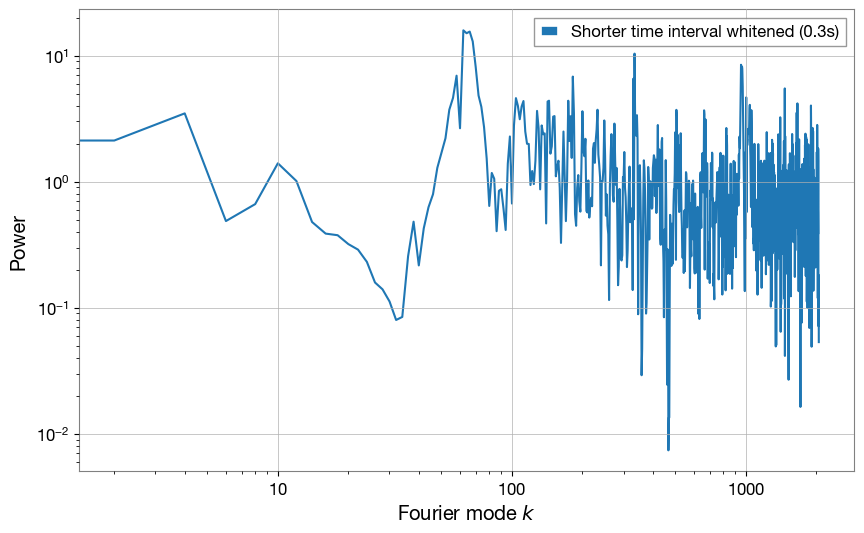

In [234]:
fig10 = plt.figure(figsize=(10,6))

# Interpolate looser and strict power spectra onto k_length grid
ps_looser_interp = np.interp(k_length, k_looser, ps_sample_looser.val)
ps_strict_interp = np.interp(k_length, k_strict, ps_sample_strict.val)
# Now ps_looser_interp, ps_strict_interp, and power_spectrum.val are on the same k grid

# plt.plot(k_length, ps_looser_interp / power_spectrum.val, label="Longer time interval whitened (0.6s)")
plt.plot(k_length, ps_strict_interp / power_spectrum.val, label="Shorter time interval whitened (0.3s)")

plt.loglog()
plt.xlabel("Fourier mode $k$")
plt.ylabel("Power")
plt.legend()
plt.show()

So indeed, even though by eye we don't see it in the previous plot 9, there is structure in the range 10-100 hertz, where we also would have expected to be structure. The main mode of the signal should be something like 1/(0.25*0.05)~80Hz, as we see in the plot approximately. It even has the shape I suggested for the signal power spectrum. I think the next modelling step would be to make a continuous double power law power spectrum, not a stitched together one and then allow for a random walk (double integrated wiener process) to maybe model the sampling noise fluctuations in this whitened power spectrum?

And as you can see the effect of the signal power in the range 10-80Hz has been diluted so heavily in the welch averaging that now in the whitening process the structure of the signal already emerges ...

If we would have e.g. used just the average of the data power spectrum sample on the shorter, the longer timescale and the random field sample shown in Fig9, we should divide out much more signal power spectrum structure in the whitening process, making the signal much more obscure:

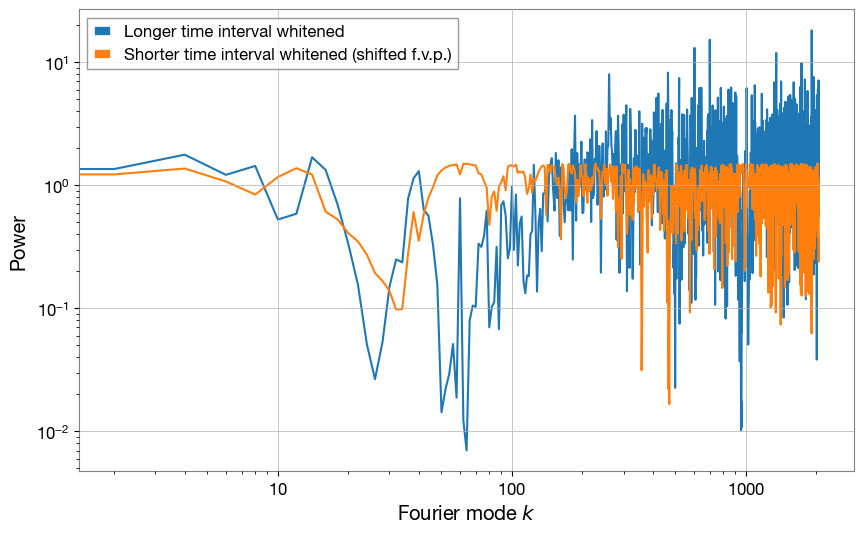

In [235]:
power_spectrum_to_norm_with = np.mean([ps_strict_interp, ps_strict_interp, power_spectrum_samples[10].val], axis=0)

fig11 = plt.figure(figsize=(10,6))

plt.plot(k_length, ps_looser_interp / power_spectrum_to_norm_with, label="Longer time interval whitened")
plt.plot(k_length, ps_strict_interp / power_spectrum_to_norm_with, label="Shorter time interval whitened (shifted f.v.p.)")

plt.loglog()
plt.xlabel("Fourier mode $k$")
plt.ylabel("Power")
plt.legend()
plt.show()

As expected this looks visually flat with a notable exception at k=90 for the blue line which I'm not quite sure what it is.
It'd be better to recalculate the welch average with less data windows and then redo this plot.

But for now:

# Conclusion

There are no visible striking features in the data power spectrum containing the signal. But whitening the latter with a power spectrum computed over the full data stream gives not exactly something white (which we would expect if the data power spectrum is the same everywhere), but something that deviates from whiteness, something structured, which must be the imprint of the signal.

I even bet the following: Think of each fourier transformed and absolute squared field as a sample from the random variable data power spectrum. All of these samples have to have approximately the same metric: The mean of their integrals MUST be very close the real space variance of the data plus minus some deviation which. The integral of the power spectra as a random variable in itself could be either gaussian or a chi^2 distribution or something; I think that then the integral over the data field would lie far away outside the mean of the integral...

I think that I could maybe calculate the variance in real space in little windows and then put the deviation in the little windows as a sigma on that number to THEN compare it in Fourier space to find that all windows show the same integral, just one exists outside the sigma bound..

## Signal Power spectrum sample over varying window lengths

In one of the last figures we saw quite clearly above average power at the appropriate frequency scales. We did not see such a feature in the very beginning (windows 15 and 16). Do the signal features completely flatten out if the fourier transform is taken over a range that includes not only the signal but a lot of noise as well?

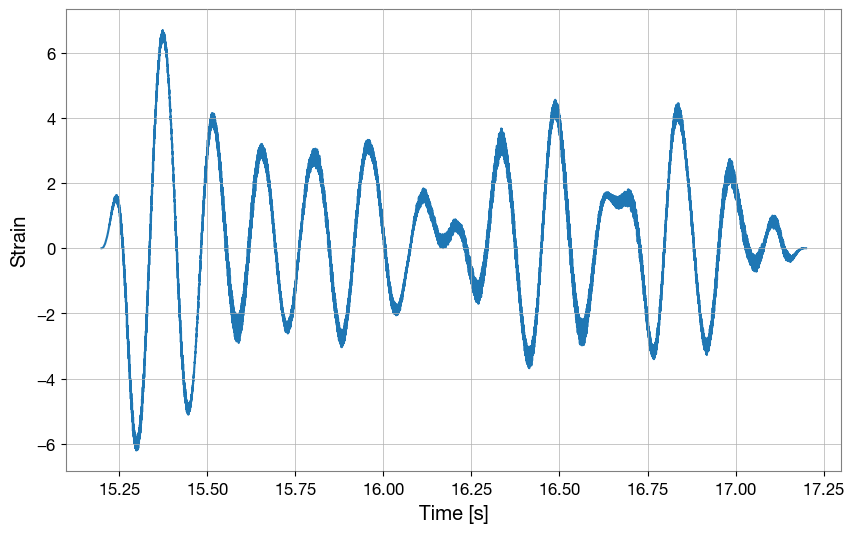

In [236]:
# redo the analysis but with a window of length 2 centered on the signal onset (as was in the welch average)

canonical_interval = np.where((time_in_strip_1 > 15.2) & (time_in_strip_2 < 17.2))
# canonical_interval = np.where((time_in_strip_1 > 15.55) & (time_in_strip_2 < 16.55))

canonical_data = data_strip_1[canonical_interval]
canonical_time = time_in_strip_1[canonical_interval]

canonical_data = canonical_data * tukey(len(canonical_data), alpha=0.1)

fig12 = plt.figure(figsize=(10,6))

plt.plot(canonical_time, canonical_data, label="'Canonical' time window")
plt.xlabel("Time [s]")
plt.ylabel("Strain")
plt.show()


In [237]:

print(canonical_time[1]-canonical_time[0])
n_dtps_canonical = len(canonical_time)  # adjust
L_canonical = max(canonical_time)-min(canonical_time) # adjust

time_domain_canonical = ift.RGSpace((n_dtps_canonical, ), distances=L_canonical/n_dtps_canonical)
time_domain_tuple_canonical= ift.DomainTuple.make(time_domain_canonical, )
HT_canonical = ift.HartleyOperator(time_domain_tuple_canonical)

window_field_canonical = ift.Field(time_domain_tuple_canonical, val=canonical_data)

tupled_result_canonical = power_analyze_my_field(window_field_canonical, HT_canonical)

k_canonical, ps_sample_canonical = tupled_result_canonical


0.000244140625


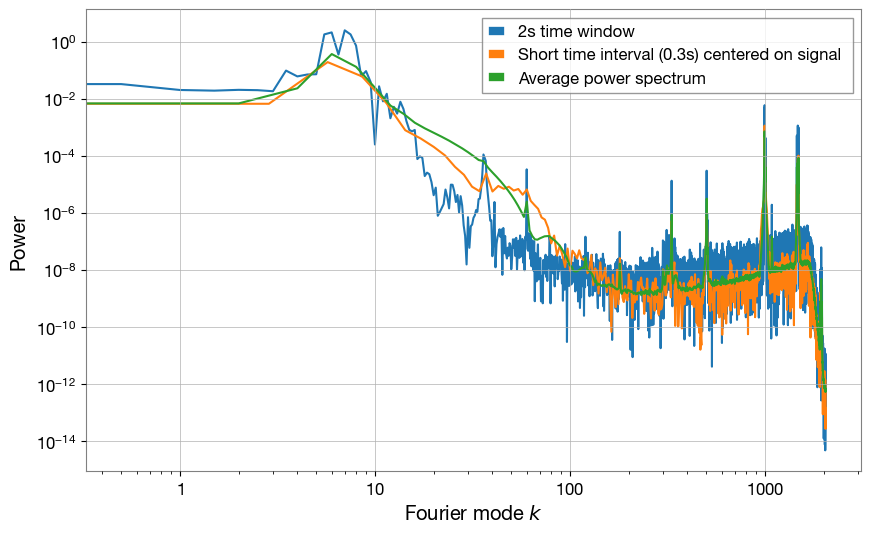

Uncomment fourier transform over 2seconds
samples that we average over:  126


In [238]:
fig13 = plt.figure(figsize=(10,6))

add_offset = False  # if false, plots all samples, not just one random and doesn't shift anything
add_bounds = False  # if True and add_offset False plots also the largest and smallest (by measure of field^T field) of the empirical power spectrum estimates in the data stream

if add_offset:
    # plt.plot(k_looser, ps_sample_looser.val, label="Longer time interval")
    plt.plot(k_canonical, ps_sample_canonical.val, label="2s time window")
    plt.plot(k_strict, ps_sample_strict.val*1e7, label="Shorter time interval (0.3s) (shifted f.v.p.)")
    plt.plot(k_length, power_spectrum.val*1e-7, label="Average power spectrum (shifted f.v.p.)")
    plt.plot(k_length, power_spectrum_samples[10].val*1e-10,  label="Random sample (shifted f.v.p.)")

else:
    # plt.plot(k_looser, ps_sample_looser.val, label="Longer time interval")

    # Uncomment here:
    plt.plot(k_canonical, ps_sample_canonical.val, label="2s time window")
    plt.plot(k_strict, ps_sample_strict.val, label="Short time interval (0.3s) centered on signal ")
    plt.plot(k_length, power_spectrum.val, label="Average power spectrum")
    for idx, el in enumerate(power_spectrum_samples):
        if (idx!=15) and (idx!=16):
            # plt.plot(k_length, el.val, alpha=0.2)
            pass
        else:
            # plt.plot(k_length, el.val, alpha=0.5, color="Black")
            pass

    if add_bounds:
        inner_products = [np.dot(arr.val, arr.val) for arr in power_spectrum_samples]  # get a metric of 'largeness'

        # Get index of maximum and min
        max_index = np.argmax(inner_products)
        min_index = np.argmin(inner_products)

        # Get the corresponding field
        max_field = power_spectrum_samples[max_index]
        min_field = power_spectrum_samples[min_index]

        plt.plot(k_length, max_field.val, label=r"Upper bound on field realizations ($\mathrm{field}_{\mathrm{max}}$)", color="blue", )
        plt.plot(k_length, min_field.val, label=r"Lower bound on field realizations ($\mathrm{field}_{\mathrm{min}}$)", color="red",)


plt.loglog()
plt.xlabel("Fourier mode $k$")
plt.ylabel("Power")
plt.legend()
plt.show()

print("Uncomment fourier transform over 2seconds")
print("samples that we average over: ", len(power_spectrum_samples))